In [138]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
PATH = r"C:/Users/admin/Downloads/Student_Performance.csv"
df = pd.read_csv(PATH)
df

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0
...,...,...,...,...,...,...
9995,1,49,Yes,4,2,23.0
9996,7,64,Yes,8,5,58.0
9997,6,83,Yes,8,5,74.0
9998,9,97,Yes,7,0,95.0


In [139]:
# No spaces found I guess
df.columns

Index(['Hours Studied', 'Previous Scores', 'Extracurricular Activities',
       'Sleep Hours', 'Sample Question Papers Practiced', 'Performance Index'],
      dtype='object')

In [140]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [141]:
# No null values either
df.isnull().sum()

Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

In [142]:
# No ? values found, that is a relief
df[(df == '?').any(axis=1)]

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index


In [143]:
# just making sure there are no other object values other than 'Yes' and 'No'
df[~((df == 'Yes') | (df == 'No')).any(axis=1)]

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index


In [144]:
df[(df == 0).any(axis=1)]

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
9,4,89,No,4,0,69.0
19,5,75,No,7,0,63.0
21,6,96,No,9,0,85.0
41,2,63,Yes,6,0,39.0
42,4,73,Yes,7,0,58.0
...,...,...,...,...,...,...
9914,4,51,Yes,8,0,28.0
9964,9,66,No,9,0,65.0
9970,9,58,Yes,9,0,55.0
9994,6,46,Yes,8,0,39.0


In [145]:
# No negative values found, except for 'Sample Question Papers Practiced' which is not relevant for this check
df_no_sample_question_papers = df.drop(columns=['Sample Question Papers Practiced'])
df[(df_no_sample_question_papers == 0).any(axis=1)]

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index


In [146]:
# No negative values either
df_drop_extracurricular_activities = df.drop(columns=['Extracurricular Activities'])
df[(df_drop_extracurricular_activities < 0).any(axis=1)]

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index


In [147]:
# There are still some duplicate rows, such a shame
df[df.duplicated()]

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
915,9,52,No,5,9,48.0
1477,7,61,Yes,6,8,54.0
1601,5,99,No,7,5,89.0
1786,2,62,Yes,9,4,40.0
2026,5,87,Yes,6,7,74.0
...,...,...,...,...,...,...
9644,4,91,Yes,4,3,71.0
9940,8,95,No,5,2,90.0
9954,6,97,No,8,7,92.0
9966,1,41,No,7,3,12.0


In [148]:
# 127 of them apparently
print(df.duplicated().sum())

127


In [149]:
# dropping those duplicate rows
df.drop_duplicates(inplace=True)

In [150]:
# And look at this, no duplicates left, horray!
df.duplicated().sum()

np.int64(0)

In [151]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9873 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     9873 non-null   int64  
 1   Previous Scores                   9873 non-null   int64  
 2   Extracurricular Activities        9873 non-null   object 
 3   Sleep Hours                       9873 non-null   int64  
 4   Sample Question Papers Practiced  9873 non-null   int64  
 5   Performance Index                 9873 non-null   float64
dtypes: float64(1), int64(4), object(1)
memory usage: 539.9+ KB


In [152]:
df.describe()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,9873.000000,9873.000000,9873.000000,9873.000000,9873.000000
mean,4.992100,69.441102,6.531652,4.583004,55.216651
std,2.589081,17.325601,1.697683,2.867202,19.208570
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,70.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


In [153]:
df

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0
...,...,...,...,...,...,...
9995,1,49,Yes,4,2,23.0
9996,7,64,Yes,8,5,58.0
9997,6,83,Yes,8,5,74.0
9998,9,97,Yes,7,0,95.0


In [154]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Extracurricular Activities'] = le.fit_transform(df['Extracurricular Activities'])

In [155]:
df

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0
2,8,51,1,7,2,45.0
3,5,52,1,5,2,36.0
4,7,75,0,8,5,66.0
...,...,...,...,...,...,...
9995,1,49,1,4,2,23.0
9996,7,64,1,8,5,58.0
9997,6,83,1,8,5,74.0
9998,9,97,1,7,0,95.0


In [156]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y = df['Performance Index']
X = df.drop(columns='Performance Index')

X_train,X_test,y_train,y_test = train_test_split(X , y , test_size=0.2, random_state=42)

In [157]:
model = LinearRegression()
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [158]:
y_predict = model.predict(X_test)

In [159]:
# Polynomial Regression
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X_train)
poly_model = LinearRegression()
poly_model.fit(X_poly, y_train)
y_poly_predict = poly_model.predict(poly.transform(X_test))

# Ridge Regression
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)
y_ridge_predict = ridge_model.predict(X_test)

# Lasso Regression
lasso_model = Lasso(alpha=1.0)
lasso_model.fit(X_train, y_train)
y_lasso_predict = lasso_model.predict(X_test)

# Decision Tree Regression
tree_model = DecisionTreeRegressor(random_state=42)
tree_model.fit(X_train, y_train)
y_tree_predict = tree_model.predict(X_test)

# Random Forest Regression
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_rf_predict = rf_model.predict(X_test)

# Support Vector Regression
svr_model = SVR(kernel='rbf')
svr_model.fit(X_train, y_train)
y_svr_predict = svr_model.predict(X_test)

In [160]:
# R2 score for each model
print(f"Linear Regression R2 Score: {r2_score(y_test, y_predict):.2f}")
print(f"Polynomial Regression R2 Score: {r2_score(y_test, y_poly_predict):.2f}")
print(f"Ridge Regression R2 Score: {r2_score(y_test, y_ridge_predict):.2f}")
print(f"Lasso Regression R2 Score: {r2_score(y_test, y_lasso_predict):.2f}")
print(f"Decision Tree Regression R2 Score: {r2_score(y_test, y_tree_predict):.2f}")
print(f"Random Forest Regression R2 Score: {r2_score(y_test, y_rf_predict):.2f}")
print(f"Support Vector Regression R2 Score: {r2_score(y_test, y_svr_predict):.2f}")

Linear Regression R2 Score: 0.99
Polynomial Regression R2 Score: 0.99
Ridge Regression R2 Score: 0.99
Lasso Regression R2 Score: 0.99
Decision Tree Regression R2 Score: 0.98
Random Forest Regression R2 Score: 0.98
Support Vector Regression R2 Score: 0.98


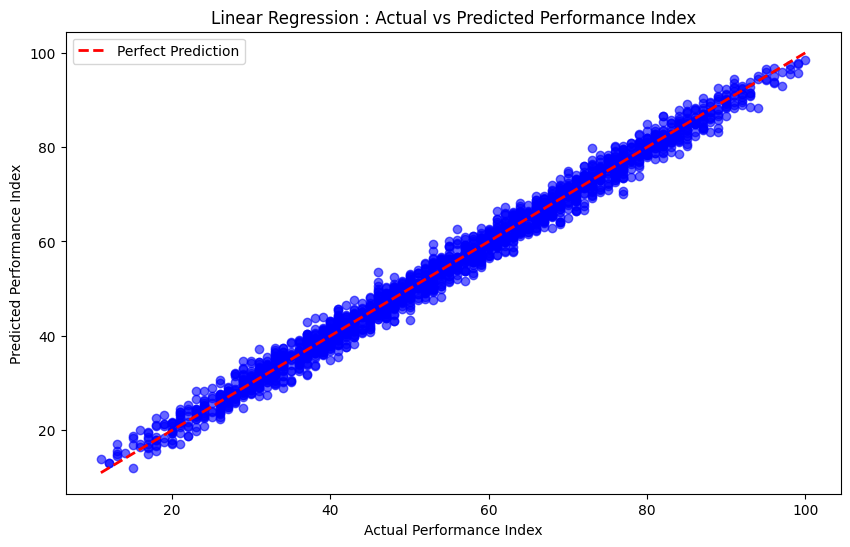

In [161]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_predict, color='blue', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel("Actual Performance Index")
plt.ylabel("Predicted Performance Index")
plt.title("Linear Regression : Actual vs Predicted Performance Index")
plt.legend()
plt.show()

In [162]:
np.sort(y_predict)

array([12.06131529, 13.00483359, 13.07974563, ..., 97.50595086,
       97.81615812, 98.36251517], shape=(1975,))

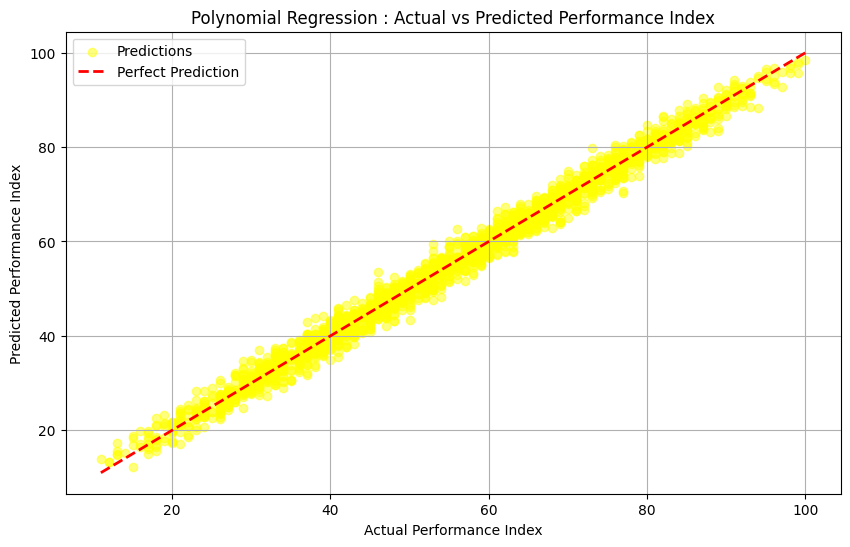

In [163]:
# Scatter plot of actual vs predicted
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_poly_predict, color='yellow', alpha=0.5, label='Predictions')

# Perfect prediction line
min_value = min(y_test.min(), y_poly_predict.min())
max_value = max(y_test.max(), y_poly_predict.max())
plt.plot([min_value, max_value], [min_value, max_value],
         color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

# Labels and title
plt.xlabel("Actual Performance Index")
plt.ylabel("Predicted Performance Index")
plt.title("Polynomial Regression : Actual vs Predicted Performance Index")
plt.legend()
plt.grid(True)
plt.show()

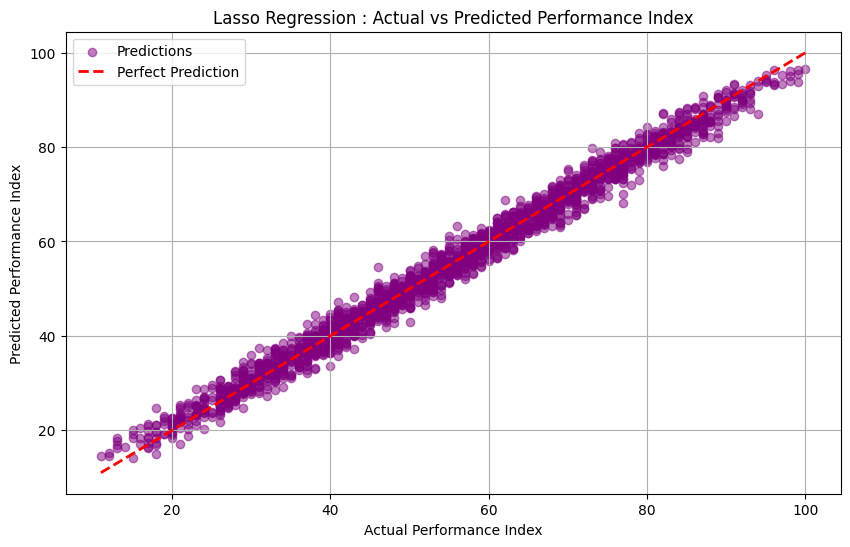

In [164]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_lasso_predict, color='purple', alpha=0.5, label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

plt.xlabel("Actual Performance Index")
plt.ylabel("Predicted Performance Index")
plt.title("Lasso Regression : Actual vs Predicted Performance Index")
plt.legend()
plt.grid(True)
plt.show()

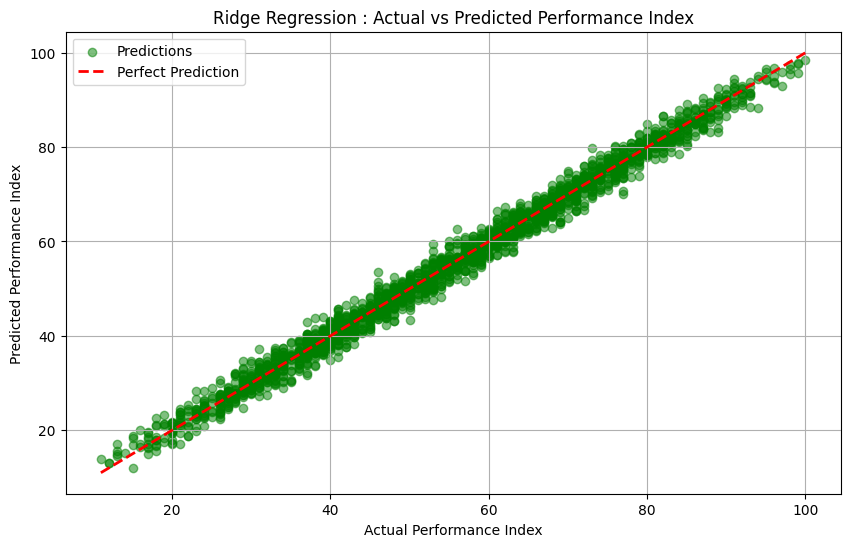

In [165]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_ridge_predict, color='green', alpha=0.5, label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

plt.xlabel("Actual Performance Index")
plt.ylabel("Predicted Performance Index")
plt.title("Ridge Regression : Actual vs Predicted Performance Index")
plt.legend()
plt.grid(True)
plt.show()

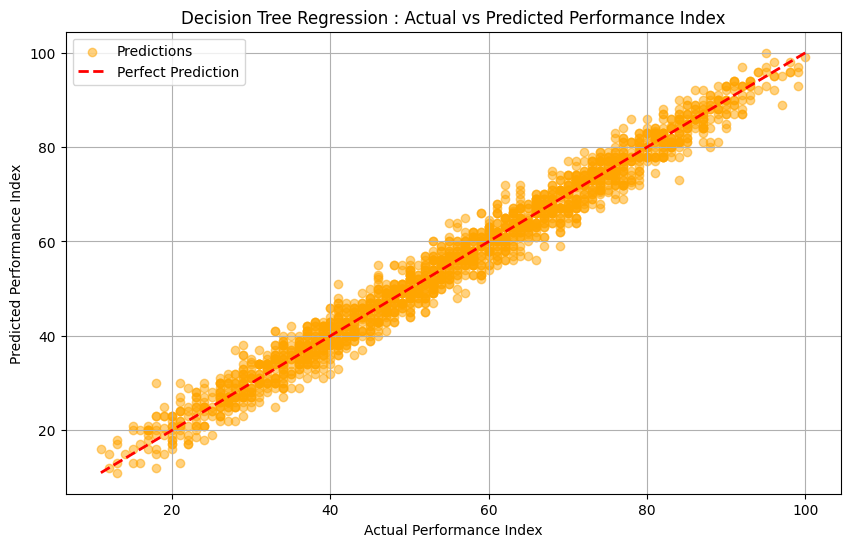

In [166]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_tree_predict, color='orange', alpha=0.5, label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

plt.xlabel("Actual Performance Index")
plt.ylabel("Predicted Performance Index")
plt.title("Decision Tree Regression : Actual vs Predicted Performance Index")
plt.legend()
plt.grid(True)
plt.show()

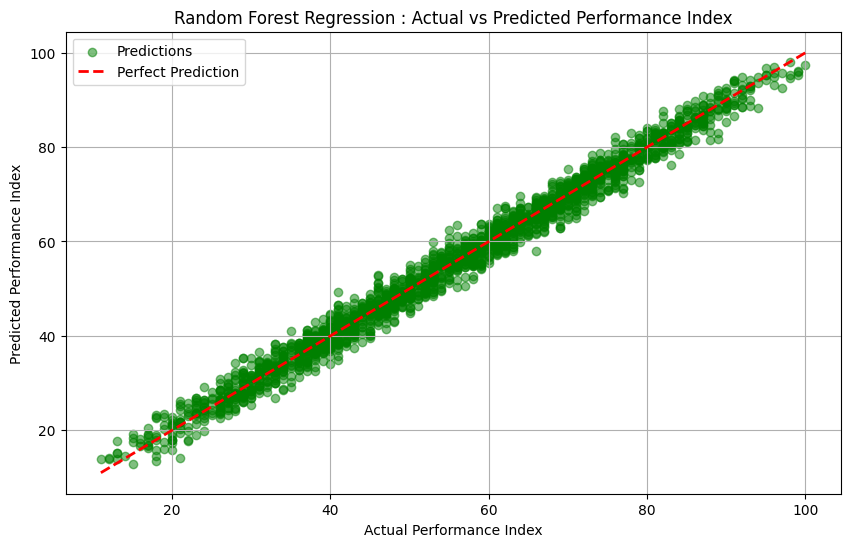

In [167]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_rf_predict, color='green', alpha=0.5, label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

plt.xlabel("Actual Performance Index")
plt.ylabel("Predicted Performance Index")
plt.title("Random Forest Regression : Actual vs Predicted Performance Index")
plt.legend()
plt.grid(True)
plt.show()

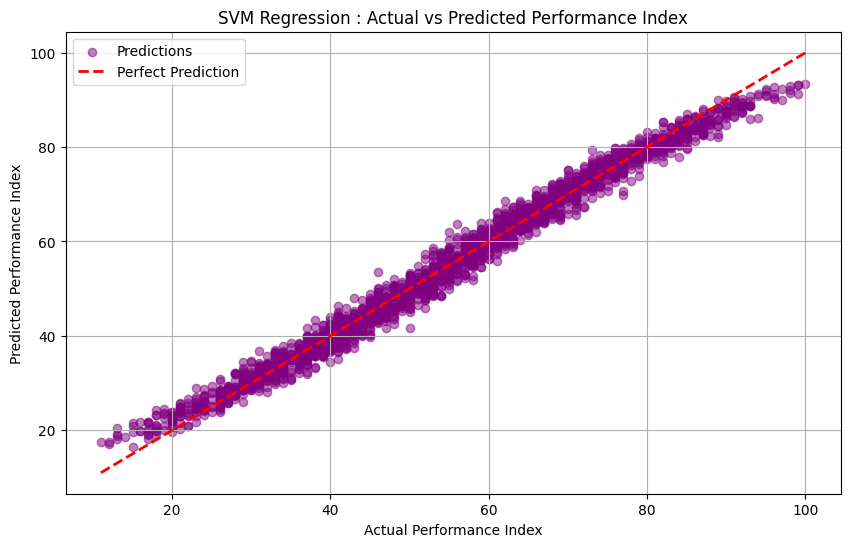

In [168]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_svr_predict, color='purple', alpha=0.5, label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

plt.xlabel("Actual Performance Index")
plt.ylabel("Predicted Performance Index")
plt.title("SVM Regression : Actual vs Predicted Performance Index")
plt.legend()
plt.grid(True)
plt.show()